Importación de paquetes necesarios

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

Importación de los dataframes curados con los compuestos y sus respectivos features

In [2]:
df_fisico = pd.read_csv('../data/processed/fisicoquimicos_filtrados.csv')
df_maccs = pd.read_csv('../data/processed/maccs_filtrados.csv')

Separamos las variables independientes (X) y la variable objetivo (y). La columna 'y' (pChEMBL_Value) es exactamente igual en ambos datasets, por lo que con importar una ya será suficiente.

In [3]:
y = df_maccs['pChEMBL_Value'].values
X_fisico = df_fisico.drop(columns=['pChEMBL_Value']).values
X_maccs = df_maccs.drop(columns=['pChEMBL_Value']).values

División Train/Test (80/20). Usamos el mismo random_state=42 para garantizar que las mismas moléculas caigan en Test para ambos modelos

In [4]:
X_train_fisiq, X_test_fisiq, y_train, y_test = train_test_split(X_fisico, y, test_size=0.2, random_state=42)
X_train_mac, X_test_mac, y_train, y_test = train_test_split(X_maccs, y, test_size=0.2, random_state=42)

Definimos y entrenamos los dos modelos Random Forest:

In [5]:
rf_fisico = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fisico.fit(X_train_fisiq, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
rf_maccs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_maccs.fit(X_train_mac, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Generamos las predicciones en el conjunto de prueba:

In [7]:
y_pred_fisico = rf_fisico.predict(X_test_fisiq)
y_pred_maccs = rf_maccs.predict(X_test_mac)

Evaluamos y comparamos los modelos independientes:

In [8]:
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.499
RMSE:     0.606


In [9]:
print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs)):.3f}")


--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.592
RMSE:     0.547


Estrategia de Consenso: Promediamos las predicciones de ambos modelos

In [10]:
y_pred_consenso = (y_pred_fisico + y_pred_maccs) / 2

print("\n--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso)):.3f}")


--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---
R2 Score: 0.584
RMSE:     0.552


Let's visualise the true vs the predicted values.

<Axes: xlabel='True', ylabel='Predicted'>

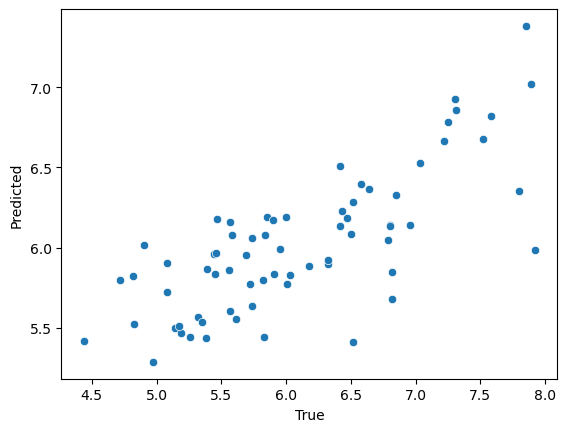

In [11]:
pred_fisico_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_fisico
     }
)
sns.scatterplot(data=pred_fisico_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

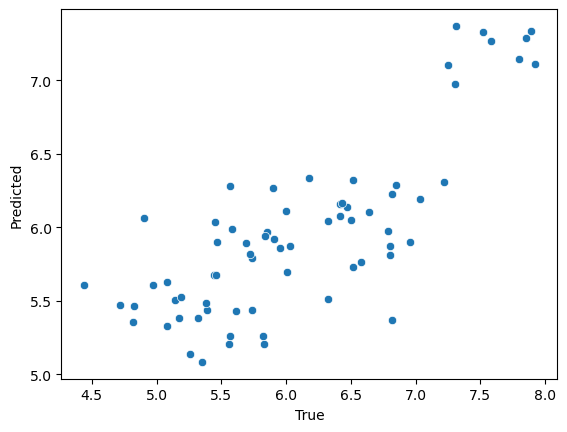

In [12]:
pred_maccs_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_maccs
     }
)
sns.scatterplot(data=pred_maccs_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

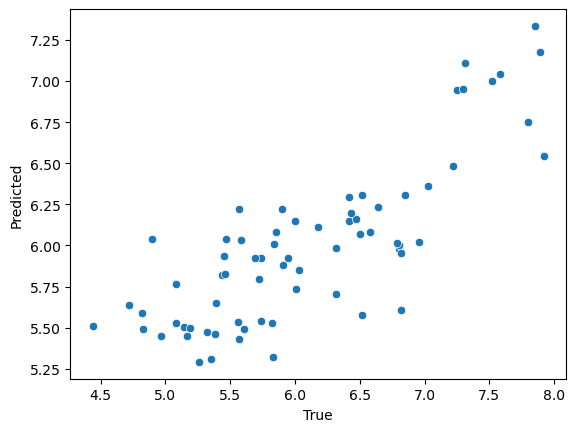

In [13]:
pred_consenso_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_consenso
     }
)
sns.scatterplot(data=pred_consenso_df, x="True", y="Predicted")